In [2]:
import pandas as pd

df = pd.read_csv("SampleSuperstore.csv")

df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [3]:
df.shape

df.info()

df.describe()

df.isnull().sum()

df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9994 non-null   object 
 1   Segment       9994 non-null   object 
 2   Country       9994 non-null   object 
 3   City          9994 non-null   object 
 4   State         9994 non-null   object 
 5   Postal Code   9994 non-null   int64  
 6   Region        9994 non-null   object 
 7   Category      9994 non-null   object 
 8   Sub-Category  9994 non-null   object 
 9   Sales         9994 non-null   float64
 10  Quantity      9994 non-null   int64  
 11  Discount      9994 non-null   float64
 12  Profit        9994 non-null   float64
dtypes: float64(3), int64(2), object(8)
memory usage: 1015.1+ KB


np.int64(17)

In [5]:
df.shape

(9994, 13)

### Observation

The dataset contains 9994 sales records and 21 features.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9994 non-null   object 
 1   Segment       9994 non-null   object 
 2   Country       9994 non-null   object 
 3   City          9994 non-null   object 
 4   State         9994 non-null   object 
 5   Postal Code   9994 non-null   int64  
 6   Region        9994 non-null   object 
 7   Category      9994 non-null   object 
 8   Sub-Category  9994 non-null   object 
 9   Sales         9994 non-null   float64
 10  Quantity      9994 non-null   int64  
 11  Discount      9994 non-null   float64
 12  Profit        9994 non-null   float64
dtypes: float64(3), int64(2), object(8)
memory usage: 1015.1+ KB


### Observation

The dataset contains both numerical and categorical columns.

In [7]:
df.describe()

,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,55190.379428,229.858001,3.789574,0.156203,28.656896
std,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,90008.000000,209.940000,5.000000,0.200000,29.364000
max,99301.000000,22638.480000,14.000000,0.800000,8399.976000


### Observation

The statistical summary provides information about sales, quantity, discount, and profit.

In [8]:
df.isnull().sum()

,0
Ship Mode,0
Segment,0
Country,0
City,0
State,0
Postal Code,0
Region,0
Category,0
Sub-Category,0
Sales,0


In [9]:
df.duplicated().sum()

np.int64(17)

In [10]:
df = df.drop_duplicates()

In [11]:
df.fillna(method='ffill', inplace=True)

/tmp/ipykernel_877/3970806690.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


In [12]:
df.isnull().sum()

,0
Ship Mode,0
Segment,0
Country,0
City,0
State,0
Postal Code,0
Region,0
Category,0
Sub-Category,0
Sales,0


In [13]:
df.columns

Index(['Ship Mode', 'Segment', 'Country', 'City', 'State', 'Postal Code',
       'Region', 'Category', 'Sub-Category', 'Sales', 'Quantity', 'Discount',
       'Profit'],
      dtype='object')

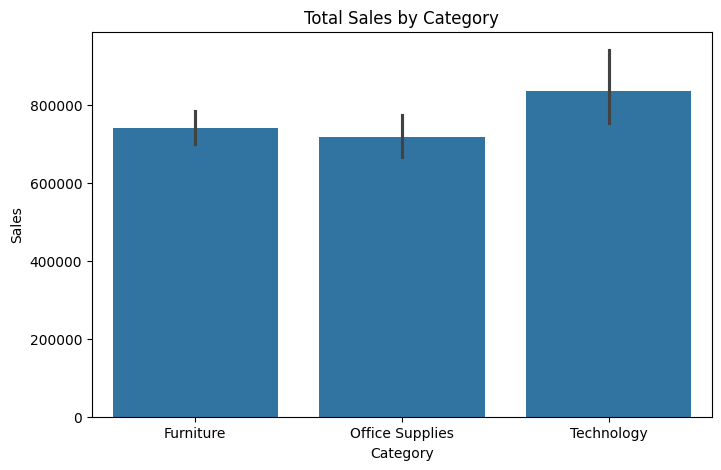

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.barplot(
    x='Category',
    y='Sales',
    data=df,
    estimator=sum
)

plt.title("Total Sales by Category")
plt.show()

### Observation

Technology generated the highest sales among all product categories.

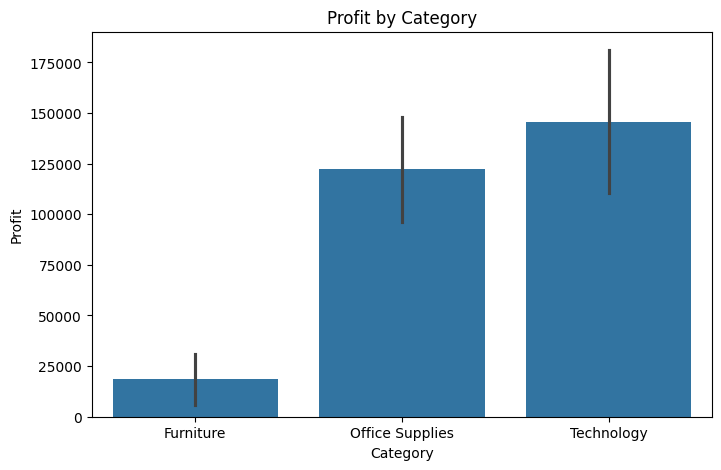

In [17]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Category',
    y='Profit',
    data=df,
    estimator=sum
)

plt.title("Profit by Category")
plt.show()

Technology generated the highest overall profit.

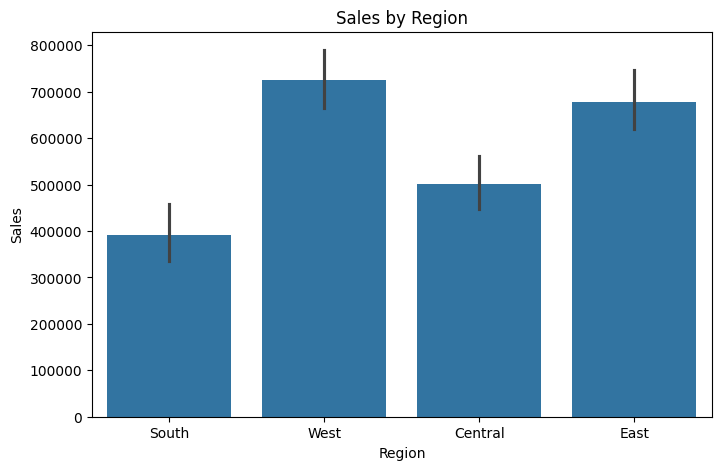

In [18]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Region',
    y='Sales',
    data=df,
    estimator=sum
)

plt.title("Sales by Region")
plt.show()

Some regions contribute significantly more sales than others.

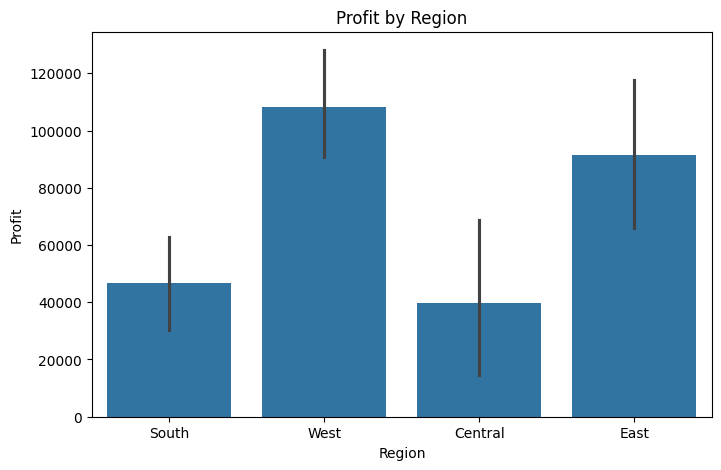

In [19]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Region',
    y='Profit',
    data=df,
    estimator=sum
)

plt.title("Profit by Region")
plt.show()

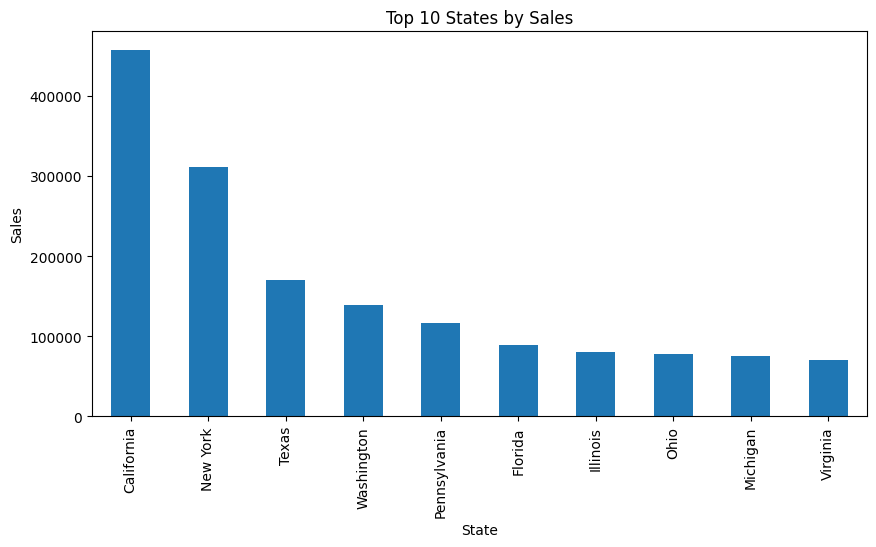

In [20]:
top_states = df.groupby('State')['Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))

top_states.plot(kind='bar')

plt.title("Top 10 States by Sales")

plt.ylabel("Sales")

plt.show()

A small number of states contribute a large portion of total sales.

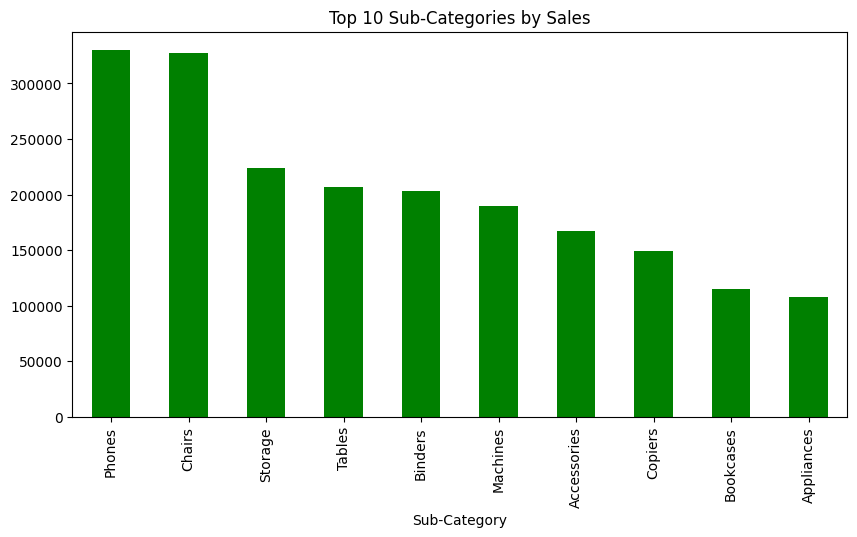

In [21]:
top_products = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))

top_products.plot(kind='bar', color='green')

plt.title("Top 10 Sub-Categories by Sales")

plt.show()

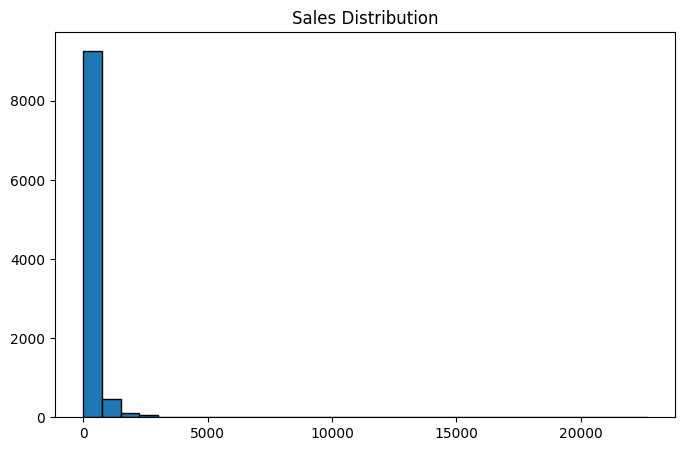

In [22]:
plt.figure(figsize=(8,5))

plt.hist(
    df['Sales'],
    bins=30,
    edgecolor='black'
)

plt.title("Sales Distribution")

plt.show()

Most orders have relatively low sales, while a few orders have very high sales.

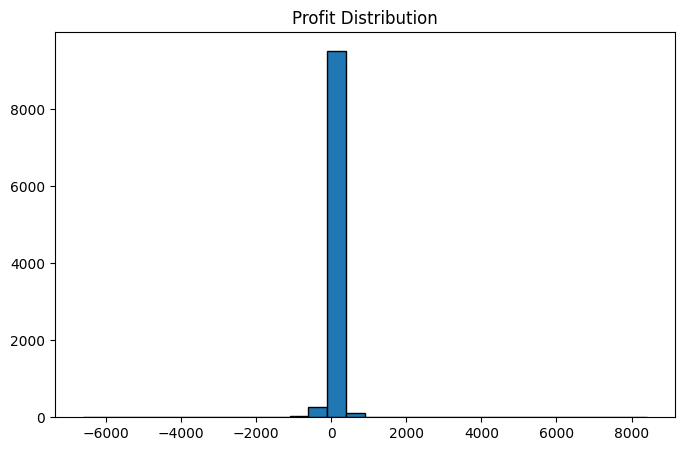

In [23]:
plt.figure(figsize=(8,5))

plt.hist(
    df['Profit'],
    bins=30,
    edgecolor='black'
)

plt.title("Profit Distribution")

plt.show()

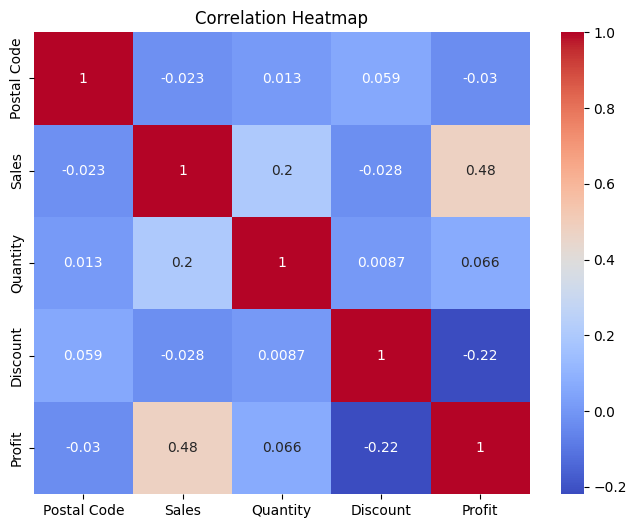

In [24]:
plt.figure(figsize=(8,6))

numeric_df = df.select_dtypes(include=['number'])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

In [26]:
print(df.columns)

Index(['Ship Mode', 'Segment', 'Country', 'City', 'State', 'Postal Code',
       'Region', 'Category', 'Sub-Category', 'Sales', 'Quantity', 'Discount',
       'Profit'],
      dtype='object')


In [27]:
print(df.columns.tolist())

['Ship Mode', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Category', 'Sub-Category', 'Sales', 'Quantity', 'Discount', 'Profit']


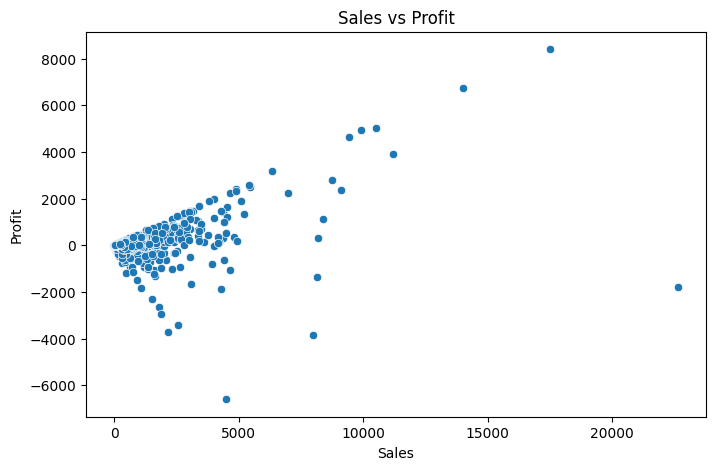

In [28]:
plt.figure(figsize=(8,5))

sns.scatterplot(x='Sales', y='Profit', data=df)

plt.title("Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")

plt.show()

### Observation

Higher sales generally lead to higher profits, but some high-sales orders still resulted in low or negative profits due to discounts or costs.

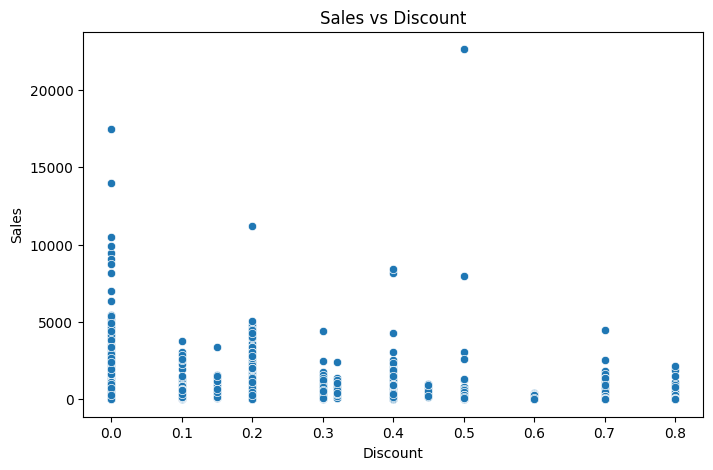

In [29]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='Discount',
    y='Sales',
    data=df
)

plt.title("Sales vs Discount")

plt.show()

### Observation

Higher discounts do not always result in higher sales.

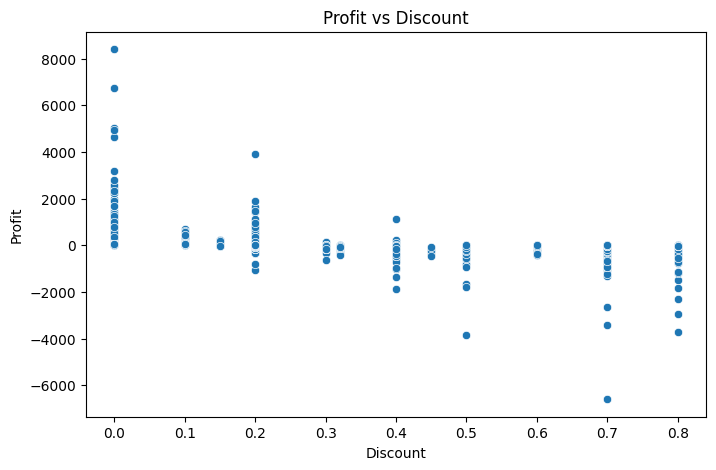

In [30]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='Discount',
    y='Profit',
    data=df
)

plt.title("Profit vs Discount")

plt.show()

### Observation

Higher discounts generally reduce profit and can even result in losses.

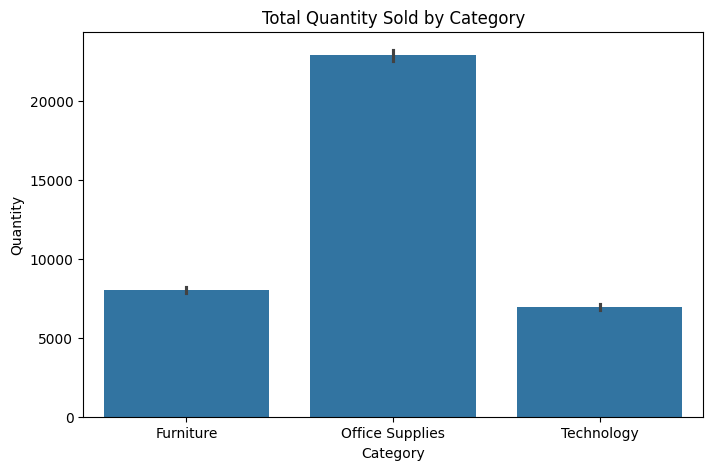

In [31]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Category',
    y='Quantity',
    data=df,
    estimator=sum
)

plt.title("Total Quantity Sold by Category")

plt.show()

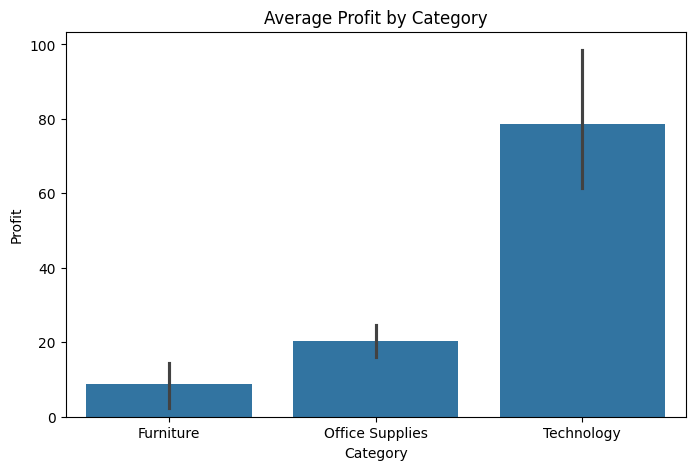

In [32]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Category',
    y='Profit',
    data=df,
    estimator='mean'
)

plt.title("Average Profit by Category")

plt.show()

In [33]:
from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [34]:
X = df[['Quantity','Discount','Profit']]

In [35]:
y = df['Sales']

In [36]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [37]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [38]:
model.fit(X_train,y_train)

RandomForestRegressor(random_state=42)

In [39]:
predictions = model.predict(X_test)


In [40]:
mae = mean_absolute_error(y_test,predictions)

rmse = mean_squared_error(
    y_test,
    predictions
)**0.5

r2 = r2_score(
    y_test,
    predictions
)

print("MAE :",mae)

print("RMSE :",rmse)

print("R2 Score :",r2)

MAE : 85.86469367575033
RMSE : 257.3765896354895
R2 Score : 0.8154968306801268


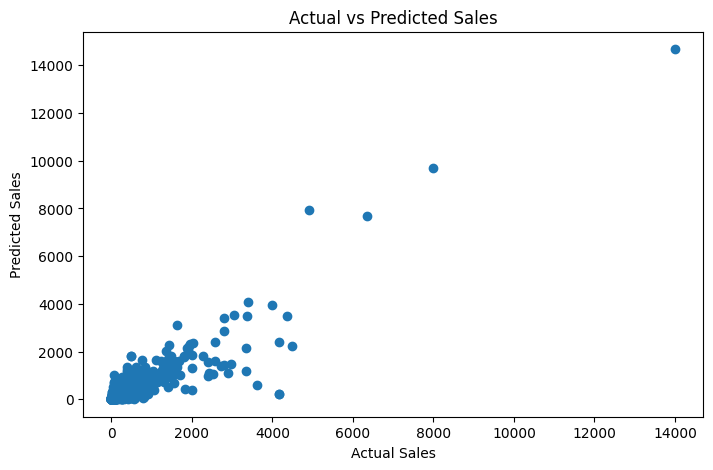

In [41]:
plt.figure(figsize=(8,5))

plt.scatter(y_test,predictions)

plt.xlabel("Actual Sales")

plt.ylabel("Predicted Sales")

plt.title("Actual vs Predicted Sales")

plt.show()

# Conclusion

## Objective

The objective of this project was to analyze retail sales data and build a machine learning model for sales prediction.

## Key Findings

- Technology category generated the highest sales.
- Some regions and states contributed significantly more revenue than others.
- Higher discounts generally reduced profitability.
- Most sales were concentrated in lower-value transactions.
- Correlation analysis helped identify relationships among sales, profit, quantity, and discount.

## Machine Learning

A Random Forest Regressor was used to predict sales based on Quantity, Discount, and Profit.

The model was evaluated using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

## Conclusion

This project demonstrates an end-to-end Data Science workflow, including data cleaning, exploratory data analysis, visualization, machine learning, and business insight generation.